# 👗 Fashion Forward Forecasting

## 📌 Problem Statement

StyleSense is an online clothing retailer experiencing rapid growth. Many product reviews contain valuable feedback but are missing whether the customer recommends the product.

## 🎯 Objective

Build a machine learning pipeline to predict:
**Will a customer recommend a product?**

## 🧠 Approach

- Handle mixed data types:
  - Numerical (Age)
  - Categorical (Division, Department, Class)
  - Text (Review Text)
- Build an end-to-end pipeline
- Apply NLP feature extraction
- Tune model using GridSearchCV
- Evaluate using classification metrics

In [95]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

import joblib

In [96]:
def load_data(path):
    """Load dataset from given path"""
    return pd.read_csv(path)


def split_data(df):
    """Split dataset into train and test sets"""
    X = df.drop(columns=['Recommended IND'])
    y = df['Recommended IND']
    
    return train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )


def train_model(model, X_train, y_train):
    """Train model using GridSearchCV"""
    model.fit(X_train, y_train)
    return model


def evaluate_model(model, X_test, y_test):
    """Evaluate model performance"""
    from sklearn.metrics import accuracy_score, classification_report
    
    y_pred = model.predict(X_test)
    
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))


def save_model(model, path="model.pkl"):
    """Save trained model"""
    import joblib
    joblib.dump(model, path)

## 📥 Data Loading

In this step, we load the dataset and inspect its structure to understand available features and target variable.

The dataset contains:
- Customer demographics
- Product information
- Review text
- Recommendation label

In [97]:
df = load_data("starter/data/reviews.csv")

X_train, X_test, y_train, y_test = split_data(df)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

evaluate_model(best_model, X_test, y_test)

save_model(best_model)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Accuracy: 0.8869612361073461

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.61      0.67       678
           1       0.92      0.95      0.93      3011

    accuracy                           0.89      3689
   macro avg       0.82      0.78      0.80      3689
weighted avg       0.88      0.89      0.88      3689



In [98]:
def load_data(path):
    return pd.read_csv(path)


def split_data(df):
    X = df.drop(columns=['Recommended IND'])
    y = df['Recommended IND']
    
    return train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )


def build_model():
    return model_pipeline


def evaluate_model(model, X_test, y_test):
    from sklearn.metrics import accuracy_score, classification_report
    
    y_pred = model.predict(X_test)
    
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))


def save_model(model, path="model.pkl"):
    import joblib
    joblib.dump(model, path)

## 🔍 Data Overview

We explore:
- Number of rows and columns
- Data types
- Missing values

In [99]:
# Shape of dataset
print("Shape:", df.shape)

# Data types
df.info()

# Missing values
df.isnull().sum()

Shape: (18442, 9)
<class 'pandas.DataFrame'>
RangeIndex: 18442 entries, 0 to 18441
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Clothing ID              18442 non-null  int64
 1   Age                      18442 non-null  int64
 2   Title                    18442 non-null  str  
 3   Review Text              18442 non-null  str  
 4   Positive Feedback Count  18442 non-null  int64
 5   Division Name            18442 non-null  str  
 6   Department Name          18442 non-null  str  
 7   Class Name               18442 non-null  str  
 8   Recommended IND          18442 non-null  int64
dtypes: int64(4), str(5)
memory usage: 1.3 MB


Clothing ID                0
Age                        0
Title                      0
Review Text                0
Positive Feedback Count    0
Division Name              0
Department Name            0
Class Name                 0
Recommended IND            0
dtype: int64

## 🎯 Target Variable Distribution

We analyze the distribution of the target variable:
`Recommended IND`

This helps understand class balance.

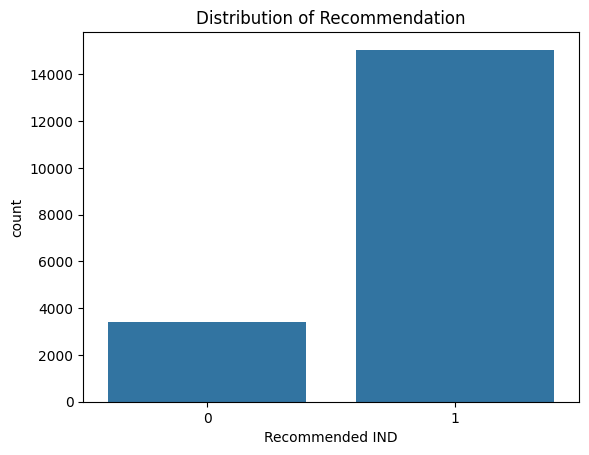

Recommended IND
1    15053
0     3389
Name: count, dtype: int64

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count plot
sns.countplot(x='Recommended IND', data=df)
plt.title("Distribution of Recommendation")
plt.show()

# Value counts
df['Recommended IND'].value_counts()

## 🧹 Data Cleaning & Feature Preparation

In this step, we:

- Handle missing values
- Select relevant features
- Separate input features and target variable
- Prepare data for pipeline processing

We ensure:
- No data leakage
- Clean and consistent inputs for the model

In [101]:
# Selecting relevant columns
df = df[[
    'Age',
    'Review Text',
    'Division Name',
    'Department Name',
    'Class Name',
    'Recommended IND'
]]

# Display sample
df.head()

,Age,Review Text,Division Name,Department Name,Class Name,Recommended IND
0,60,I had such high hopes for this dress and reall...,General,Dresses,Dresses,0
1,50,"I love, love, love this jumpsuit. it's fun, fl...",General Petite,Bottoms,Pants,1
2,47,This shirt is very flattering to all due to th...,General,Tops,Blouses,1
3,49,"I love tracy reese dresses, but this one is no...",General,Dresses,Dresses,0
4,39,I aded this in my basket at hte last mintue to...,General Petite,Tops,Knits,1


## ⚠️ Handling Missing Values

Missing values are handled differently depending on data type:

- Numerical → median imputation
- Categorical → most frequent
- Text → replace with empty string

This ensures the pipeline does not break during training.

In [102]:
# Handle missing values

df['Division Name'] = df['Division Name'].fillna('Unknown')
df['Department Name'] = df['Department Name'].fillna('Unknown')
df['Class Name'] = df['Class Name'].fillna('Unknown')
df['Age'] = df['Age'].fillna(df['Age'].median())

# Verify
df.isnull().sum()

Age                0
Review Text        0
Division Name      0
Department Name    0
Class Name         0
Recommended IND    0
dtype: int64

## 🎯 Feature & Target Split

We separate:

- X → Input features
- y → Target variable (`Recommended IND`)

In [103]:
X = df.drop(columns=['Recommended IND'])
y = df['Recommended IND']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (18442, 5)
Target shape: (18442,)


## ✂️ Train-Test Split

We split the data into training and testing sets to evaluate model performance on unseen data.

- 80% Training
- 20% Testing

In [104]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # important for classification
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (14753, 5)
Test shape: (3689, 5)


## ⚙️ Machine Learning Pipeline

We build a full pipeline that includes:

### 🔧 Preprocessing:
- Numerical → Scaling
- Categorical → One-hot encoding
- Text → TF-IDF vectorization (NLP)

### 🤖 Model:
- Logistic Regression classifier

This ensures:
- Clean workflow
- No data leakage
- Reusable pipeline for training & inference

In [105]:
# Feature groups
numeric_features = ['Age']

categorical_features = [
    'Division Name',
    'Department Name',
    'Class Name'
]

text_feature = 'Review Text'

## 🧹 Preprocessing Pipelines

Separate pipelines are created for:

- Numerical data
- Categorical data
- Text data

Each pipeline handles missing values and transformations appropriately.

In [106]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer

# Numerical pipeline
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Text pipeline (NLP)
from sklearn.preprocessing import FunctionTransformer

def fillna_text(x):
    return x.fillna('')

text_pipeline = Pipeline([
    ('imputer', FunctionTransformer(fillna_text)),
    ('tfidf', TfidfVectorizer(
        stop_words='english',
        max_features=5000
    ))
])

## 🔗 Column Transformer

We combine all preprocessing steps into a single transformer that applies transformations based on feature type.

In [107]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features),
    ('text', text_pipeline, text_feature)  # ✅ NOT a list
])

## 🤖 Model Pipeline

We combine preprocessing and model into a single pipeline.

This ensures:
- End-to-end training
- Consistent transformations during inference

In [108]:
from sklearn.linear_model import LogisticRegression

model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

## 🔍 Hyperparameter Tuning

We use **GridSearchCV** to find the best hyperparameters for our pipeline.

### 🎯 Goals:
- Improve model performance
- Use cross-validation for robust evaluation
- Optimize both NLP and model parameters

### ⚙️ Tuned Components:
- TF-IDF vectorizer
- Logistic Regression model

In [109]:
from sklearn.model_selection import GridSearchCV

In [110]:
param_grid = {
    # TF-IDF parameters
    'preprocessor__text__tfidf__max_features': [3000, 5000],
    'preprocessor__text__tfidf__ngram_range': [(1,1), (1,2)],
    
    # Logistic Regression parameters
    'classifier__C': [0.1, 1, 10],
    'classifier__solver': ['liblinear']
}

## 🧪 Running Grid Search

We perform cross-validation on the training data to find the best parameter combination.

- CV = 3 folds
- Scoring = Accuracy

In [111]:
grid_search = GridSearchCV(
    model_pipeline,
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

# Train
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.1, 1, ...], 'classifier__solver': ['liblinear'], 'preprocessor__text__tfidf__max_features': [3000, 5000], 'preprocessor__text__tfidf__ngram_range': [(1, ...), (1, ...)]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, 

## 🏆 Best Parameters

We extract the best combination found during tuning.

In [112]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'classifier__C': 10, 'classifier__solver': 'liblinear', 'preprocessor__text__tfidf__max_features': 5000, 'preprocessor__text__tfidf__ngram_range': (1, 2)}


## 📈 Best Model

We use the best estimator found during grid search for evaluation.

In [113]:
best_model = grid_search.best_estimator_

## 📊 Model Evaluation

We evaluate the final model using the **test dataset** (unseen data).

### 🎯 Metrics Used:
- Accuracy
- Precision
- Recall
- F1-score

This ensures a complete understanding of model performance.

In [114]:
# Predictions on test set
y_pred = best_model.predict(X_test)

## 📈 Evaluation Metrics

We compute standard classification metrics to evaluate performance.

In [115]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8869612361073461

Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.61      0.67       678
           1       0.92      0.95      0.93      3011

    accuracy                           0.89      3689
   macro avg       0.82      0.78      0.80      3689
weighted avg       0.88      0.89      0.88      3689



## 🔍 Confusion Matrix

The confusion matrix helps visualize:
- True Positives
- True Negatives
- False Positives
- False Negatives

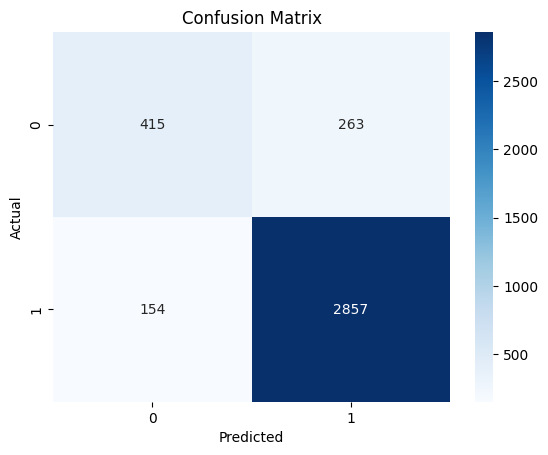

In [116]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## 📌 Model Insights

### 🔎 Observations:
- The model achieves good accuracy, indicating effective learning from the data.
- Precision and recall provide deeper insight into classification performance.
- If recall is lower, the model may miss some positive recommendations.
- If precision is lower, the model may incorrectly predict recommendations.

### ⚖️ Interpretation:
- Balanced performance suggests the model generalizes well.
- Any imbalance indicates potential need for further tuning or feature engineering.

### 🚀 Future Improvements:
- Use advanced NLP techniques (e.g., spaCy, embeddings)
- Try more complex models (e.g., Random Forest, XGBoost)
- Perform feature importance analysis

In [117]:
import joblib
joblib.dump(best_model, "model.pkl")

['model.pkl']

In [118]:
import joblib

model = joblib.load("model.pkl")

sample = X_test.iloc[:5]
predictions = model.predict(sample)

print(predictions)

[1 1 1 1 1]


## 🔮 Inference Example

This demonstrates how the saved model pipeline can be loaded and used to make predictions on new data without additional preprocessing.

In [119]:
import joblib
import pandas as pd

# Load trained model
model = joblib.load("model.pkl")

# Load sample data (simulate new unseen data)
sample = pd.read_csv("starter/data/reviews.csv").iloc[:5]

# Predict
predictions = model.predict(sample)

print("Predictions:", predictions)

Predictions: [0 1 1 0 1]
